In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
config = {
    "resolution": 256,
    "batch_size": 64,
    "codebook_size": 1024,
    "codebook_dim": 256,                       # back to 256
    "encoder_channels": [128, 256, 256, 512],  # back to original
    "commitment_beta": 0.25,
    "ema_decay": 0.99,
    "lr": 3e-4,
    "epochs": 100,
    "device": "cuda",
}

In [ ]:
from datasets import load_dataset
from torch.utils.data import Dataset
from torch.utils.data import Subset

class CelebAHF(Dataset):
    def __init__(self, split, transform):
        self.ds = load_dataset("flwrlabs/celeba", split=split)
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image = self.ds[idx]["image"]  # PIL image
        return self.transform(image), 0  # return 0 as dummy label to match old interface

from torchvision import transforms as T

transform_pipeline = T.Compose([
    T.CenterCrop(178),
    T.Resize(256),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

dataset_train = CelebAHF("train", transform=transform_pipeline)
dataset_val = CelebAHF("valid", transform=transform_pipeline)
dataset_train = Subset(dataset_train, range(20000))
dataset_val = Subset(dataset_val, range(2000))

train_dataloader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_dataloader = torch.utils.data.DataLoader(
    dataset_val,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

img_align+identity+attr/train-00000-of-0(…):   0%|          | 0.00/500M [00:00<?, ?B/s]

img_align+identity+attr/train-00001-of-0(…):   0%|          | 0.00/498M [00:00<?, ?B/s]

...

Generating valid split:   0%|          | 0/19867 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19962 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self,  input_dim, output_dim):
    super().__init__()
    self.conv1=nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=2, padding=1)
    self.norm=nn.BatchNorm2d(output_dim)
    self.relu=nn.ReLU()
    self.conv2=nn.Conv2d(output_dim, output_dim, kernel_size=3, stride=1, padding=1)
    self.norm2=nn.BatchNorm2d(output_dim)
    self.relu2=nn.ReLU()
  def forward(self, x):
    x=self.conv1(x)
    x=self.norm(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.norm2(x)
    x=self.relu2(x)
    return x

In [ ]:
class EncoderModule(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.encoders=nn.Sequential(EncoderBlock( 3, 128), EncoderBlock(128, 256), EncoderBlock(256, 256), EncoderBlock(256, 512))
    self.final=nn.Conv2d(512, config["codebook_dim"], kernel_size=1)
  def forward(self, x):
    x=self.encoders(x)
    x=self.final(x)
    return x

In [ ]:
class VectorQuantizer(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.K=config["codebook_size"]
    self.D=config["codebook_dim"]
    self.commitment_beta=config["commitment_beta"]
    self.ema_decay=config["ema_decay"]
    self.steps=0
    self.codebook=nn.Embedding(self.K, self.D)
    nn.init.normal_(self.codebook.weight)
    self.register_buffer("ema_cluster_size", torch.zeros(self.K))
    self.register_buffer("ema_weight_sum", torch.zeros(self.K, self.D))
    self.register_buffer("usage_count", torch.zeros(self.K))
  def forward(self, x):
    B,D,H,W=x.shape
    x_permuted=x.permute(0,2,3,1)
    x_flattened=torch.flatten(x_permuted, 0, 2)

    x_L2=(x_flattened**2).sum(dim=1, keepdim=True)
    cb_sq=(self.codebook.weight**2).sum(dim=1, keepdim=False)
    cross=x_flattened @ self.codebook.weight.T
    distances=x_L2 - 2*cross +cb_sq

    indices=torch.argmin(distances, dim=1)

    lookup=self.codebook(indices)

    if self.training:
      with torch.no_grad():
        one_hot = F.one_hot(indices, num_classes=self.K).float()
        new_count = one_hot.sum(dim=0)
        new_weight_sum = one_hot.T @ x_flattened

        self.ema_cluster_size.mul_(self.ema_decay).add_(new_count * (1 - self.ema_decay))
        self.ema_weight_sum.mul_(self.ema_decay).add_(new_weight_sum * (1 - self.ema_decay))

        self.codebook.weight.data = self.ema_weight_sum / (self.ema_cluster_size.unsqueeze(1) + 1e-6)
        self.usage_count.add_(new_count)
        self.steps += 1
        if self.steps % 50 == 0:
          dead = (self.usage_count < 1.0).nonzero(as_tuple=True)[0]
          if len(dead) > 0:
            random_indices = torch.randint(0, x_flattened.shape[0], (len(dead),))
            self.codebook.weight.data[dead] = x_flattened[random_indices].detach()
            self.usage_count[dead] = 1.0
    x_new=lookup.reshape( B,H,W,D)

    x_back=x_new.permute(0,3,1,2)

    straight_through=x + (x_back-x).detach()

    loss=self.commitment_beta * F.mse_loss(x, x_back.detach())

    return straight_through, loss, indices.reshape(B,H,W)

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.upsample=nn.Upsample(scale_factor=2, mode="nearest")
    self.conv=nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.batchnorm=nn.BatchNorm2d(out_channels)
    self.relu=nn.ReLU()
    self.conv2=nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
    self.batchnorm2=nn.BatchNorm2d(out_channels)
    self.relu2=nn.ReLU()
  def forward(self, x):
    x=self.upsample(x)
    x=self.conv(x)
    x=self.batchnorm(x)
    x=self.relu(x)
    x=self.conv2(x)
    x=self.batchnorm2(x)
    x=self.relu2(x)
    return x

In [ ]:
class Decoder(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.conv_project=nn.Conv2d(config["codebook_dim"],512,kernel_size=1)
    self.decoders=nn.Sequential(DecoderBlock(512, 256), DecoderBlock(256, 256), DecoderBlock(256, 128), DecoderBlock(128,128))
    self.final_conv=nn.Conv2d(128, 3, kernel_size=3, padding=1)
    self.tanh=nn.Tanh()
  def forward(self, x):
    x=self.conv_project(x)
    x=self.decoders(x)
    x=self.final_conv(x)
    x=self.tanh(x)
    return x

In [ ]:
class VQ_VAE(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.encoder=EncoderModule(config)
    self.quantizer=VectorQuantizer(config)
    self.decoder=Decoder(config)
  def forward(self, x):
    z_e=self.encoder(x)
    z_q, commit_loss, indices=self.quantizer(z_e)
    x_recon=self.decoder(z_q)
    return x_recon, commit_loss, indices


In [ ]:
def vq_vae_loss(x_recon, x, commit_loss):
    recon_loss = F.mse_loss(x_recon, x)
    total_loss = recon_loss + commit_loss
    return total_loss, recon_loss, commit_loss

In [ ]:
model = VQ_VAE(config).to(config["device"])
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
train_losses = []
val_losses = []

for epoch in range(config["epochs"]):
    # --- Train ---
    model.train()
    total_train_loss = 0
    total_recon_loss = 0
    total_commit_loss = 0
    num_batches = 0

    for batch in train_dataloader:
        images, _ = batch
        images = images.to(config["device"])

        optimizer.zero_grad()
        x_recon, q_loss, indices = model(images)
        total_loss, recon_loss, commit_loss = vq_vae_loss(x_recon, images, q_loss)
        total_loss.backward()
        optimizer.step()

        total_train_loss += total_loss.item()
        total_recon_loss += recon_loss.item()
        total_commit_loss += commit_loss.item()
        num_batches += 1

    total_train_loss /= num_batches
    total_recon_loss /= num_batches
    total_commit_loss /= num_batches
    train_losses.append(total_train_loss)

    # --- Val ---
    model.eval()
    total_val_loss = 0
    total_val_recon = 0
    total_val_commit = 0
    num_val_batches = 0

    with torch.no_grad():
        for batch in val_dataloader:
            images, _ = batch
            images = images.to(config["device"])

            x_recon, q_loss, indices = model(images)
            total_loss, recon_loss, commit_loss = vq_vae_loss(x_recon, images, q_loss)

            total_val_loss += total_loss.item()
            total_val_recon += recon_loss.item()
            total_val_commit += commit_loss.item()
            num_val_batches += 1

    total_val_loss /= num_val_batches
    total_val_recon /= num_val_batches
    total_val_commit /= num_val_batches
    val_losses.append(total_val_loss)

    # --- Codebook utilization ---
    utilization = (model.quantizer.usage_count > 0).float().mean().item()
    model.quantizer.usage_count.zero_()

    print(
        f"Epoch {epoch+1}/{config['epochs']} | "
        f"train: {total_train_loss:.4f} (recon: {total_recon_loss:.4f}, commit: {total_commit_loss:.4f}) | "
        f"val: {total_val_loss:.4f} (recon: {total_val_recon:.4f}, commit: {total_val_commit:.4f}) | "
        f"codebook: {utilization*100:.1f}%"
    )

Epoch 1/100 | train: 0.0445 (recon: 0.0394, commit: 0.0051) | val: 0.0242 (recon: 0.0214, commit: 0.0028) | codebook: 100.0%
Epoch 2/100 | train: 0.0231 (recon: 0.0207, commit: 0.0024) | val: 0.0202 (recon: 0.0178, commit: 0.0024) | codebook: 100.0%
Epoch 3/100 | train: 0.0199 (recon: 0.0178, commit: 0.0021) | val: 0.0207 (recon: 0.0183, commit: 0.0024) | codebook: 100.0%
Epoch 4/100 | train: 0.0188 (recon: 0.0166, commit: 0.0021) | val: 0.0177 (recon: 0.0155, commit: 0.0022) | codebook: 100.0%
Epoch 5/100 | train: 0.0179 (recon: 0.0156, commit: 0.0023) | val: 0.0188 (recon: 0.0160, commit: 0.0028) | codebook: 100.0%
Epoch 6/100 | train: 0.0170 (recon: 0.0146, commit: 0.0024) | val: 0.0160 (recon: 0.0136, commit: 0.0024) | codebook: 100.0%
Epoch 7/100 | train: 0.0167 (recon: 0.0142, commit: 0.0025) | val: 0.0160 (recon: 0.0132, commit: 0.0028) | codebook: 100.0%
Epoch 8/100 | train: 0.0165 (recon: 0.0139, commit: 0.0026) | val: 0.0152 (recon: 0.0126, commit: 0.0026) | codebook: 100.0%


KeyboardInterrupt: 

In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

model = VQ_VAE(config).to(config["device"])
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

# single batch test
batch = next(iter(train_dataloader))
images, _ = batch
images = images.to(config["device"])

x_recon, q_loss, indices = model(images)
total_loss, recon_loss, commit_loss = vq_vae_loss(x_recon, images, q_loss)
total_loss.backward()

peak = torch.cuda.max_memory_allocated() / 1024**3
print(f"Peak VRAM with batch_size=64: {peak:.2f} GB")

Peak VRAM with batch_size=64: 40.40 GB


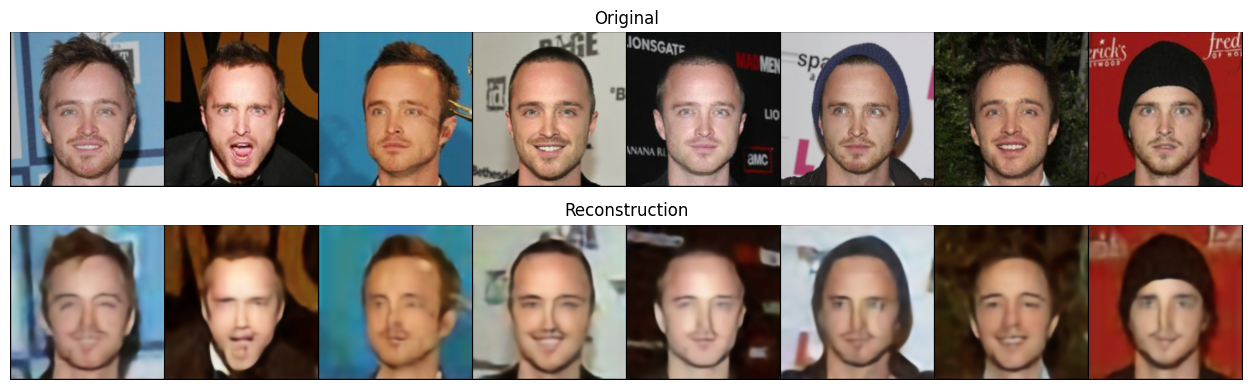

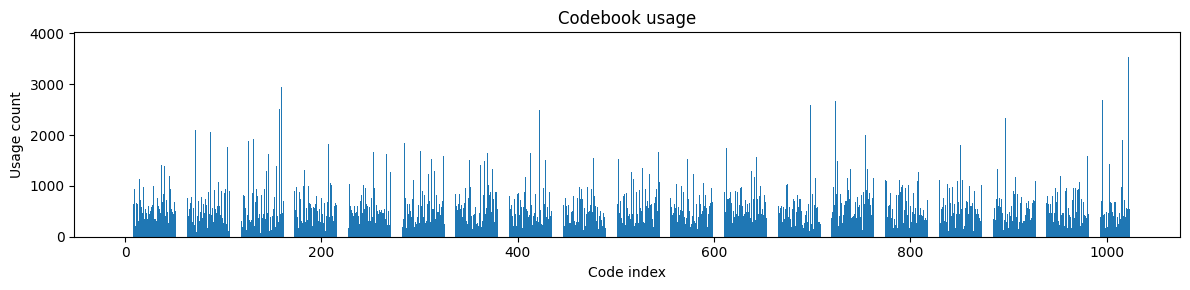

In [ ]:
import torchvision.utils as vutils
model.eval()
with torch.no_grad():
    batch, _ = next(iter(val_dataloader))
    images = batch[:8].to(config["device"])
    x_recon, _, _ = model(images)

# denormalize from [-1, 1] to [0, 1]
images = images * 0.5 + 0.5
x_recon = x_recon * 0.5 + 0.5
images = images.clamp(0, 1)
x_recon = x_recon.clamp(0, 1)

# reconstruction grid
orig_grid = vutils.make_grid(images.cpu(), nrow=8)
recon_grid = vutils.make_grid(x_recon.cpu(), nrow=8)

fig, axes = plt.subplots(2, 1, figsize=(16, 4))
axes[0].imshow(orig_grid.permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(recon_grid.permute(1, 2, 0))
axes[1].set_title("Reconstruction")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# codebook usage histogram
usage = model.quantizer.usage_count.cpu().numpy()
plt.figure(figsize=(12, 3))
plt.bar(range(len(usage)), usage)
plt.title("Codebook usage")
plt.xlabel("Code index")
plt.ylabel("Usage count")
plt.tight_layout()
plt.show()